#  Notebook 1: Analyse des Données

## Projet Anti-Spam Intelligent - BMSecurity

**Objectif:** Comprendre notre dataset d'emails avant de créer un modèle de détection de spam.

### Ce qu'on va faire:
1. Charger les données
2. Explorer la structure du dataset
3. Vérifier les valeurs manquantes
4. Vérifier les doublons
5. Voir la distribution spam vs ham
6. Créer des WordClouds

---

## Étape 1: Importer les bibliothèques

On importe les outils dont on a besoin pour travailler avec les données.

In [12]:
# Importer pandas pour manipuler les données
import pandas as pd

# Importer matplotlib et seaborn pour les graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Importer wordcloud pour les nuages de mots
from wordcloud import WordCloud

# Configuration des graphiques
plt.style.use('default')

print("✅ Bibliothèques importées!")

✅ Bibliothèques importées!


## Étape 2: Charger le dataset

On charge notre fichier CSV contenant les emails.

In [13]:
# Charger le fichier CSV
df = pd.read_csv('../DataSet_Emails/DataSet_Emails.csv',index_col=0)

# Voir les 5 premières lignes
print("Voici les premières lignes du dataset:")
df.head()

Voici les premières lignes du dataset:


,message_id,text,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


## Étape 3: Explorer la structure du dataset

Regardons combien de lignes et colonnes on a, et quels types de données.

In [14]:
# Taille du dataset (lignes, colonnes)
print("Taille du dataset:")
print(f"  - Nombre de lignes (emails): {df.shape[0]}")
print(f"  - Nombre de colonnes: {df.shape[1]}")
print()

# Liste des colonnes
print("Les colonnes disponibles:")
print(df.columns.tolist())

Taille du dataset:
  - Nombre de lignes (emails): 31716
  - Nombre de colonnes: 7

Les colonnes disponibles:
['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']


In [15]:
# Informations sur les types de données
print("Informations sur le dataset:")
df.info()

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 31716 entries, 0 to 31715
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   message_id  31716 non-null  int64 
 1   text        31665 non-null  object
 2   label       31716 non-null  int64 
 3   label_text  31716 non-null  object
 4   subject     31442 non-null  object
 5   message     31371 non-null  object
 6   date        31716 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.9+ MB


## Étape 4: Vérifier les valeurs manquantes

On regarde s'il y a des données manquantes dans notre dataset.

In [16]:
# Compter les valeurs manquantes par colonne
print("Valeurs manquantes par colonne:")
print(df.isnull().sum())
print()
print(f"Total de valeurs manquantes: {df.isnull().sum().sum()}")

Valeurs manquantes par colonne:
message_id      0
text           51
label           0
label_text      0
subject       274
message       345
date            0
dtype: int64

Total de valeurs manquantes: 670


## Étape 5: Vérifier les doublons

On vérifie s'il y a des emails en double.

In [17]:
# Compter les doublons
doublons = df.duplicated().sum()
print(f"Nombre de lignes en double: {doublons}")

# Doublons basés sur le texte seulement
doublons_text = df.duplicated(subset=['text']).sum()
print(f"Nombre de textes en double: {doublons_text}")

Nombre de lignes en double: 0
Nombre de textes en double: 2904


## Étape 6: Distribution des classes (Spam vs Ham)

On regarde combien on a de spam et combien de ham (emails légitimes).

In [18]:
# Compter les spam et ham
print("Distribution des classes:")
print(df['label_text'].value_counts())
print()

# Pourcentages
print("Pourcentages:")
print(df['label_text'].value_counts(normalize=True) * 100)

Distribution des classes:
label_text
spam    16163
ham     15553
Name: count, dtype: int64

Pourcentages:
label_text
spam    50.96166
ham     49.03834
Name: proportion, dtype: float64


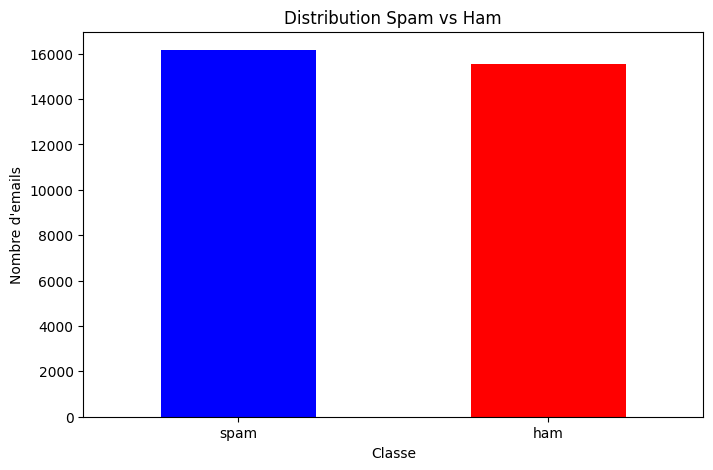

In [19]:
# Visualiser avec un graphique en barres
plt.figure(figsize=(8, 5))
df['label_text'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution Spam vs Ham')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'emails')
plt.xticks(rotation=0)
plt.show()

## Étape 7: WordClouds (Nuages de mots)

On visualise les mots les plus fréquents dans les emails spam et ham.

In [26]:
# Séparer les emails spam et ham
spam_emails = df[df['label_text'] == 'spam']['text']
ham_emails = df[df['label_text'] == 'ham']['text']

print(spam_emails.head())

# Combiner tous les textes
spam_text = ' '.join(spam_emails.dropna().astype(str))
ham_text = ' '.join(ham_emails.dropna().astype(str))

print(f"Nombre d'emails spam: {len(spam_emails)}")
print(f"Nombre d'emails ham: {len(ham_emails)}")

0    any software just for 15 $ - 99 $ understandin...
2    wanted to try ci 4 lis but thought it was way ...
4    looking for cheap high - quality software ? ro...
5    emerging growth stock profile vera ,\nvcsc - b...
6    internet provider abuse i noticed that you hav...
Name: text, dtype: object
Nombre d'emails spam: 16163
Nombre d'emails ham: 15553


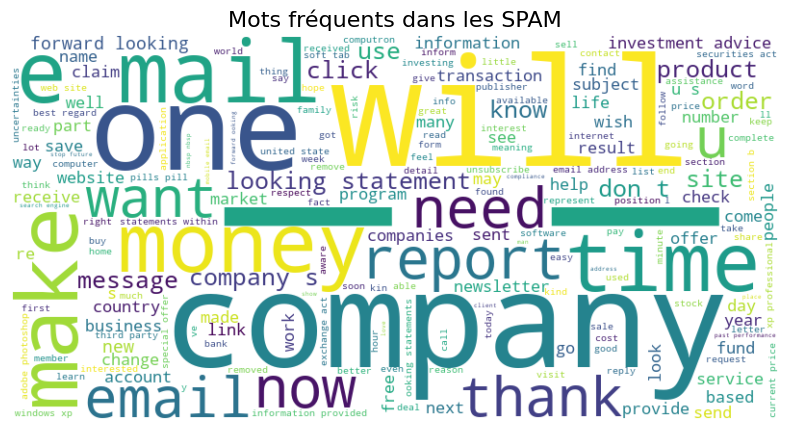

In [21]:
# Créer le WordCloud pour les SPAM
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Mots fréquents dans les SPAM', fontsize=16)
plt.axis('off')
plt.show()

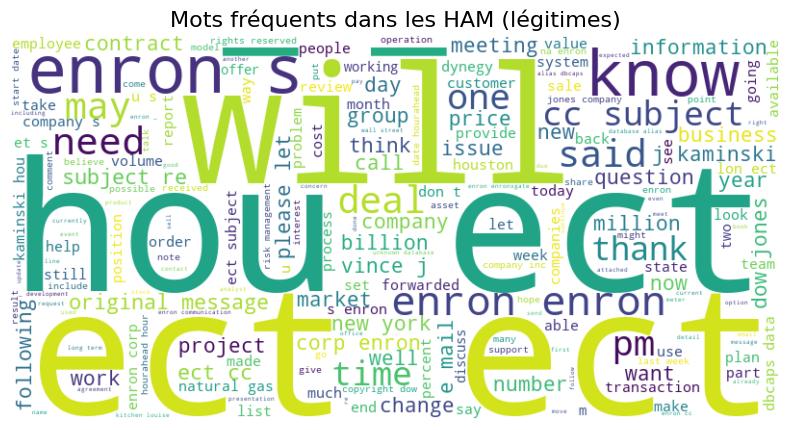

In [22]:
# Créer le WordCloud pour les HAM (emails légitimes)
wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Mots fréquents dans les HAM (légitimes)', fontsize=16)
plt.axis('off')
plt.show()

## ✅ Résumé de l'analyse

**Ce qu'on a appris:**
- Structure du dataset (colonnes, types de données)
- Présence ou non de valeurs manquantes
- Présence ou non de doublons
- Distribution des classes spam/ham
- Mots fréquents dans chaque catégorie

**Prochaine étape:** Notebook 2 - Prétraitement du texte